#### Disclaimer
Note: The dataset used in this analysis is synthetic and solely used for application of concepts only. The statistical relationships, coefficients, and significance levels observed are generated for practice and demonstration purposes only and hence maybe supurious. These results should not be used to draw clinical, financial, or policy conclusions regarding real-world healthcare systems or patient outcomes.

#### Objective
- To estimate the association between socioeconomic, demographic, and health-related factors and healthcare costs and health outcomes using classical econometric models.

Research Question
- What factors are associated with healthcare costs and health outcomes after controlling for observable confounders?

Model Setup

Outcome variables:
- Healthcare costs: billing_amount
- Health outcome (binary): indicator derived from test_results or admission severity

Key covariates:
- Age
- Gender
- Insurance status
- Medical condition
- Admission type

#### Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")


#### Import the dataset

In [2]:
df = pd.read_csv("health_data_cleaned.csv")
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28131,328,Urgent,02-02-2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.32729,265,Emergency,26-08-2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.09608,205,Emergency,07-10-2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78241,450,Elective,18-12-2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.31781,458,Urgent,09-10-2022,Penicillin,Abnormal


#### Baseline OLS model: healthcare costs
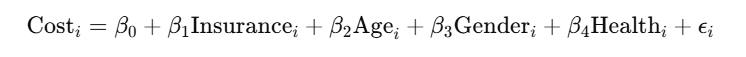


In [3]:

# Fit OLS with Robust Standard Errors (HC3)
ols_formula = "billing_amount ~ age + C(gender) + C(insurance_provider) + C(medical_condition) + C(admission_type)"
ols_model = smf.ols(ols_formula, data=df).fit(cov_type='HC3')

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:         billing_amount   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.186
Date:                Sun, 21 Dec 2025   Prob (F-statistic):              0.282
Time:                        23:08:35   Log-Likelihood:            -6.0942e+05
No. Observations:               55500   AIC:                         1.219e+06
Df Residuals:                   55486   BIC:                         1.219e+06
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

#### Muticolinearity check

In [21]:
# Create the design matrix for VIF
from patsy import dmatrices
y, X = dmatrices("log_billing ~ age + gender + insurance_provider + medical_condition", 
                 data=df, return_type='dataframe')

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data.sort_values(by="VIF", ascending=False))


--- Variance Inflation Factor (VIF) ---
                                   Feature        VIF
0                                Intercept  18.030767
8            medical_condition[T.Diabetes]   1.663691
9        medical_condition[T.Hypertension]   1.660496
10            medical_condition[T.Obesity]   1.659854
7              medical_condition[T.Cancer]   1.659581
6              medical_condition[T.Asthma]   1.657432
3              insurance_provider[T.Cigna]   1.619804
4           insurance_provider[T.Medicare]   1.616248
5   insurance_provider[T.UnitedHealthcare]   1.615324
2         insurance_provider[T.Blue Cross]   1.613031
11                                     age   1.000106
1                           gender[T.Male]   1.000081


#### Normality of the residuals

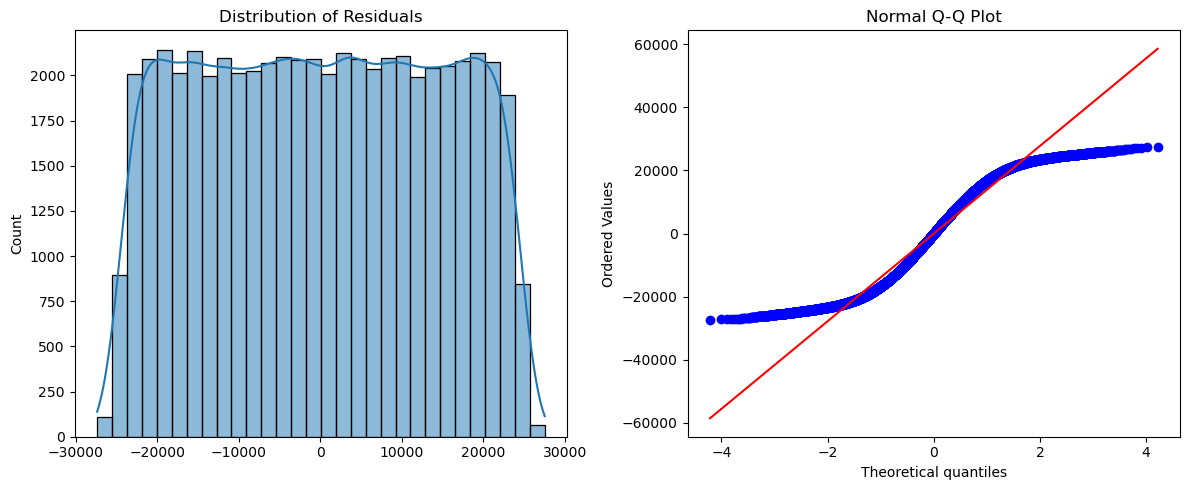

In [6]:
from scipy import stats   

# Residual diagnostics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of residuals
sns.histplot(ols_model.resid, bins=30, kde=True, ax=ax1)
ax1.set_title("Distribution of Residuals")

# Q-Q Plot
stats.probplot(ols_model.resid, dist="norm", plot=ax2)
ax2.set_title("Normal Q-Q Plot")

plt.tight_layout()
plt.show()


#### Linearity and Homoscedasticity (Residuals vs. Fitted)

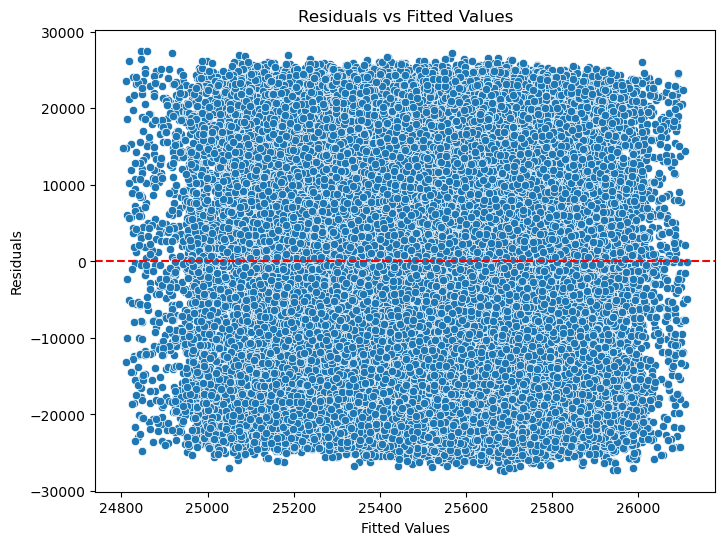

In [7]:
# Residuals vs Fitted values
fitted_vals = ols_model.fittedvalues
residuals = ols_model.resid

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

#### Log Linear Model

In [8]:
# Transform dependent variable
df['log_billing'] = np.log(df['billing_amount'] + 1)

# Fit Log-Linear Model
log_ols = smf.ols("log_billing ~ age + C(gender) + C(insurance_provider) + C(medical_condition) + C(admission_type)", 
                  data=df).fit(cov_type='HC3')

print(log_ols.summary())

                            OLS Regression Results                            
Dep. Variable:            log_billing   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.591
Date:                Sun, 21 Dec 2025   Prob (F-statistic):             0.0795
Time:                        23:11:46   Log-Likelihood:                -69233.
No. Observations:               55392   AIC:                         1.385e+05
Df Residuals:                   55378   BIC:                         1.386e+05
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

#### Check for the Normality of the residuals

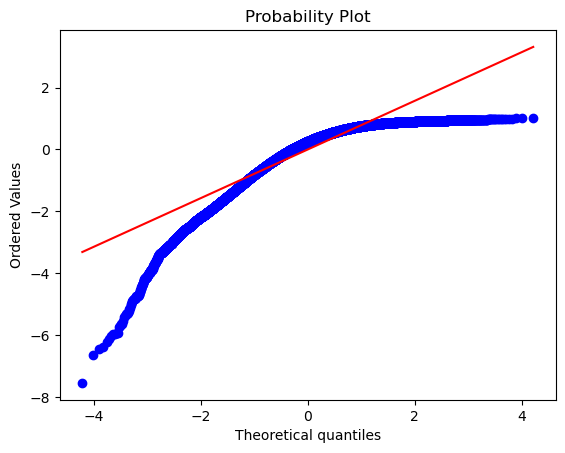

In [9]:
stats.probplot(log_ols.resid, dist="norm", plot=plt)
plt.show()

#### Residual distribution

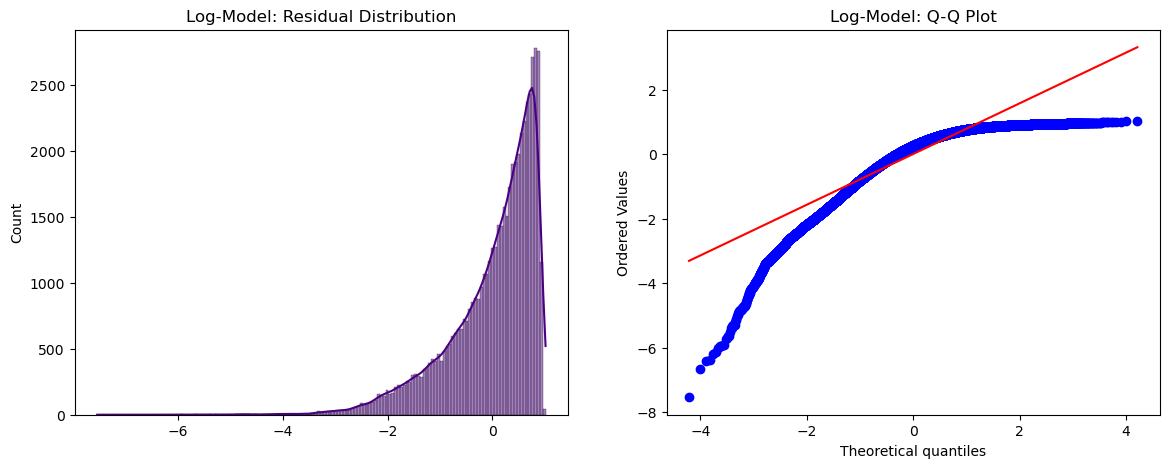

In [10]:
import scipy.stats as stats

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram should look more symmetric now
sns.histplot(log_ols.resid, kde=True, ax=ax[0], color='indigo')
ax[0].set_title("Log-Model: Residual Distribution")

# Q-Q plot should stay closer to the red line
stats.probplot(log_ols.resid, dist="norm", plot=ax[1])
ax[1].set_title("Log-Model: Q-Q Plot")

plt.show()

#### Linearity Check

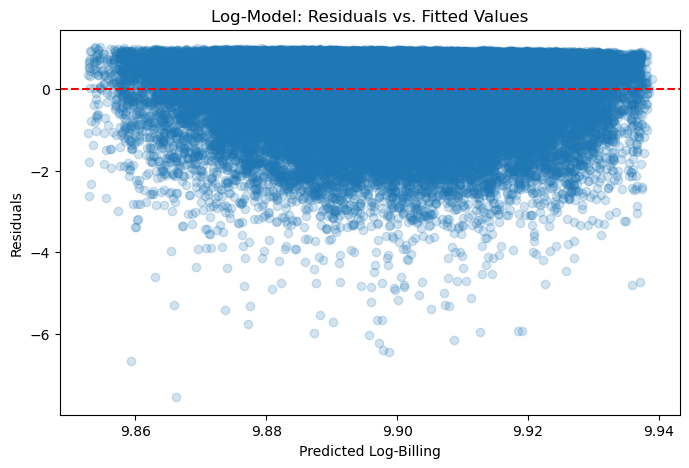

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(log_ols.fittedvalues, log_ols.resid, alpha=0.2)
plt.axhline(0, color='red', linestyle='--')
plt.title("Log-Model: Residuals vs. Fitted Values")
plt.xlabel("Predicted Log-Billing")
plt.ylabel("Residuals")
plt.show()

#### Logistic regression

#### Create a binary health indicator

In [12]:
#Create the binary outcome based on admission severity
df['poor_health'] = (df['admission_type'] == 'Emergency').astype(int)

#Fit the Logit Model
logit_model = smf.logit(
    "poor_health ~ age + C(gender) + C(insurance_provider)",
    data=df
).fit()

logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.633512
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            poor_health   No. Observations:                55500
Model:                          Logit   Df Residuals:                    55493
Method:                           MLE   Df Model:                            6
Date:                Sun, 21 Dec 2025   Pseudo R-squ.:               0.0001237
Time:                        23:12:05   Log-Likelihood:                -35160.
converged:                       True   LL-Null:                       -35164.
Covariance Type:            nonrobust   LLR p-value:                    0.1914
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -0.6609      0.033    -20.287      0.000      -0.725      -0.597
C(gender)[T.Male]                            -0.0385      0.018     -2.132      0.033      -0.074      -0.003
C(insurance_provider)[T.Blue Cross]          -0.0392      0.029     -1.367      0.172      -0.095       0.017
C(insurance_provider)[T.Cigna]               -0.0449      0.029     -1.574      0.115      -0.101       0.011
C(insurance_provider)[T.Medicare]            -0.0330      0.029     -1.155      0.248      -0.089       0.023
C(insurance_provider)[T.UnitedHealthcare]    -0.0544      0.029     -1.899      0.058      -0.111       0.002
age                                        4.966e-05      0.000      0.108      0.914      -0.001       0.001
=============================================================================================================
"""

#### Get the marginal effects

In [13]:
print(logit_model.get_margeff().summary())

        Logit Marginal Effects       
Dep. Variable:            poor_health
Method:                          dydx
At:                           overall
                                               dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
C(gender)[T.Male]                            -0.0085      0.004     -2.132      0.033      -0.016      -0.001
C(insurance_provider)[T.Blue Cross]          -0.0086      0.006     -1.367      0.171      -0.021       0.004
C(insurance_provider)[T.Cigna]               -0.0099      0.006     -1.574      0.115      -0.022       0.002
C(insurance_provider)[T.Medicare]            -0.0073      0.006     -1.155      0.248      -0.020       0.005
C(insurance_provider)[T.UnitedHealthcare]    -0.0120      0.006     -1.899      0.058      -0.024       0.000
age                                        1.096e-05      0.000      0.108    

#### Computing the odds ratio

In [14]:
# Calculate Odds Ratios
odds_ratios = np.exp(logit_model.params)
conf = np.exp(logit_model.conf_int())
conf['Odds Ratio'] = odds_ratios
conf.columns = ['5%', '95%', 'Odds Ratio']
print(conf)

                                                 5%       95%  Odds Ratio
Intercept                                  0.484449  0.550436    0.516389
C(gender)[T.Male]                          0.928731  0.996896    0.962210
C(insurance_provider)[T.Blue Cross]        0.909091  1.017119    0.961589
C(insurance_provider)[T.Cigna]             0.904068  1.011076    0.956076
C(insurance_provider)[T.Medicare]          0.914852  1.023261    0.967540
C(insurance_provider)[T.UnitedHealthcare]  0.895362  1.001741    0.947059
age                                        0.999147  1.000953    1.000050


In [ ]:
# Calculate Marginal Effects
margeff = logit_model.get_margeff()
print(margeff.summary())

#### Classification report

In [16]:
import statsmodels.formula.api as smf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
# 1. Create the binary outcome (ensuring the column exists)
df['poor_health'] = (df['admission_type'] == 'Emergency').astype(int)

# 2. Fit the Logit Model
logit_model = smf.logit(
    "poor_health ~ age + C(gender) + C(insurance_provider) + C(medical_condition)", 
    data=df
).fit()

# 3. Generate Predictions
# We get the probability, then convert to 0 or 1 using a 0.5 threshold
df['prob_poor_health'] = logit_model.predict(df)
df['predicted_class'] = (df['prob_poor_health'] > 0.5).astype(int)

# 4. Diagnostics: Classification Report
# We use 'poor_health' here because that's what we defined above
print("\n--- Logistic Model Performance ---")
print(classification_report(df["poor_health"], df["predicted_class"]))

Optimization terminated successfully.
         Current function value: 0.633448
         Iterations 4

--- Logistic Model Performance ---
              precision    recall  f1-score   support

           0       0.67      1.00      0.80     37231
           1       0.00      0.00      0.00     18269

    accuracy                           0.67     55500
   macro avg       0.34      0.50      0.40     55500
weighted avg       0.45      0.67      0.54     55500



#### Roc Curve

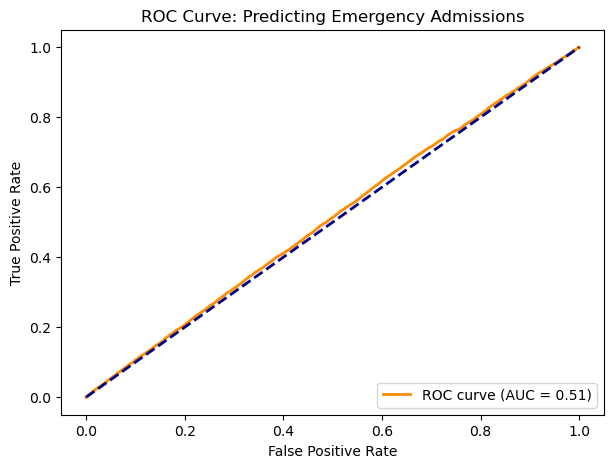

In [17]:
# Calculate ROC metrics
fpr, tpr, thresholds = roc_curve(df['poor_health'], df['prob_poor_health'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Predicting Emergency Admissions')
plt.legend(loc="lower right")
plt.show()

#### Confusion Matrix

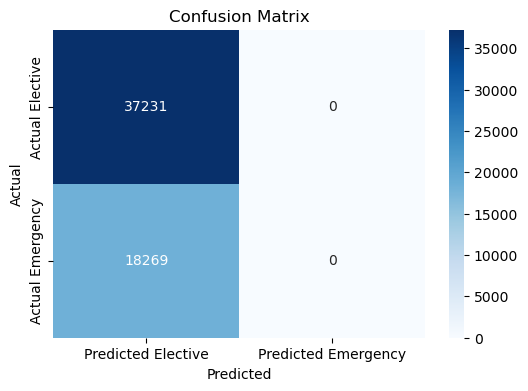

In [18]:
cm = confusion_matrix(df["poor_health"], df["predicted_class"])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Elective', 'Predicted Emergency'],
            yticklabels=['Actual Elective', 'Actual Emergency'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

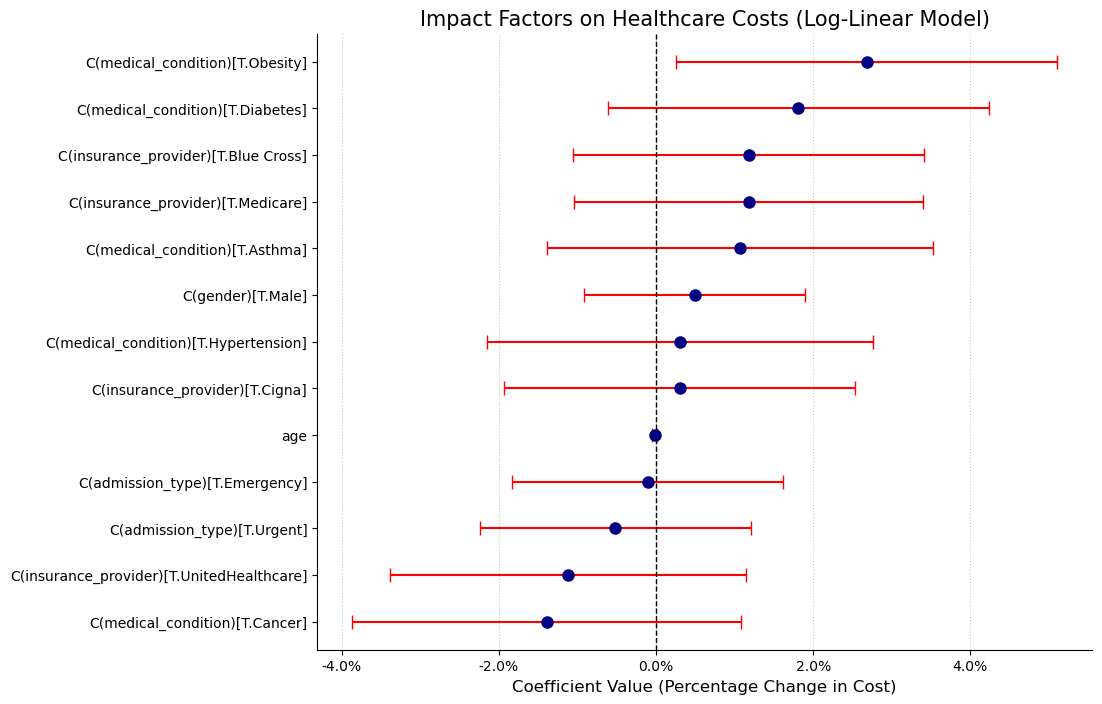

In [19]:
#  Extract coefficients and confidence intervals from the Log-Linear model
params = log_ols.params[1:]  # Exclude the intercept
conf = log_ols.conf_int()[1:]
results_df = pd.DataFrame({
    'Feature': params.index,
    'Coefficient': params.values,
    'Lower CI': conf[0].values,
    'Upper CI': conf[1].values
})

# Sort by coefficient magnitude for better readability
results_df = results_df.sort_values(by='Coefficient')

# 3. Create the Coefficient Plot
plt.figure(figsize=(10, 8))
plt.errorbar(results_df['Coefficient'], results_df['Feature'], 
             xerr=[results_df['Coefficient'] - results_df['Lower CI'], 
                   results_df['Upper CI'] - results_df['Coefficient']],
             fmt='o', color='navy', ecolor='red', capsize=5, markersize=8)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title("Impact Factors on Healthcare Costs (Log-Linear Model)", fontsize=15)
plt.xlabel("Coefficient Value (Percentage Change in Cost)", fontsize=12)
plt.grid(True, axis='x', linestyle=':', alpha=0.7)

# Format the x-axis to show percentage interpretation
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))

sns.despine()
plt.show()